In [82]:
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
results = pd.read_csv('./evaluation_results/eval_results_2025-11-17_22-26-33.csv')
results

,question,datetime,model_name,ground_truth,model_output,chunk_retrieval_time,generation_time,bleu,rouge,precision,recall,F1,recall@k,precision@k
0,How will the freshwater canal be designed in t...,2025-11-17 22:13:38.308414,qwen3:4b,The freshwater canal will have nature-friendly...,"Based solely on the provided document context,...",0.198282,112.874046,0.024414,0.068111,tensor([0.7590]),tensor([0.8441]),tensor([0.7993]),1.0,0.6
1,What are the yearly costs for above ground dri...,2025-11-17 22:15:36.411865,qwen3:4b,"Yearly, above ground drip irrigation costs bet...","Based on the provided document context, I cann...",0.291917,114.080366,0.086330,0.093750,tensor([0.7949]),tensor([0.8775]),tensor([0.8341]),1.0,0.2
2,What pre-treatment steps were applied before N...,2025-11-17 22:16:48.631576,qwen3:4b,"Coagulation, flocculation, lamella seperation,...","Based solely on the provided document context,...",0.198088,67.444995,0.003265,0.007634,tensor([0.7721]),tensor([0.8030]),tensor([0.7873]),0.0,0.0
3,For which types of wastewaters is anaerobic tr...,2025-11-17 22:17:27.036817,qwen3:4b,anaerobic treatment is most convenient for som...,"Based solely on the provided document context,...",0.208651,35.978331,0.173301,0.442308,tensor([0.8563]),tensor([0.8994]),tensor([0.8773]),1.0,1.0
4,What was the purpose of the trials conducted a...,2025-11-17 22:18:43.130743,qwen3:4b,The purpose of the trials at Dow Terneuzen wit...,"Based solely on the provided document context,...",0.243151,71.016391,0.036001,0.153846,tensor([0.8084]),tensor([0.9078]),tensor([0.8552]),1.0,0.6
5,What is the observed effect of raising the gro...,2025-11-17 22:20:00.163631,qwen3:4b,Farmers have not observed any negative effects...,"Based solely on the provided document context,...",0.218298,72.497496,0.111016,0.130000,tensor([0.7938]),tensor([0.8740]),tensor([0.8319]),0.0,0.0
6,Which companies were involved in the Hergebrui...,2025-11-17 22:21:02.252790,qwen3:4b,"The companies involved were Kloosterboer B.V.,...","Based solely on the provided document context,...",0.193645,57.995736,0.012263,0.048309,tensor([0.7771]),tensor([0.7979]),tensor([0.7873]),1.0,0.2
7,How will the freshwater canal be designed in t...,2025-11-17 22:23:33.003082,qwen3:4b,The freshwater canal will have nature-friendly...,"Based solely on the provided document context,...",0.214661,145.403672,0.027148,0.080268,tensor([0.7741]),tensor([0.8522]),tensor([0.8113]),1.0,0.6
8,Which techniques were used in the GO-Fresh fie...,2025-11-17 22:25:10.369985,qwen3:4b,Three techniques: (1) Kreekrug Infiltratie Sys...,"Based solely on the provided document context,...",0.192997,93.031191,0.009005,0.066914,tensor([0.7859]),tensor([0.8151]),tensor([0.8002]),1.0,0.2
9,What was the purpose of the trials conducted a...,2025-11-17 22:26:33.437091,qwen3:4b,The purpose of the trials at Dow Terneuzen wit...,"Based solely on the provided document context,...",0.217312,79.018459,0.067128,0.187755,tensor([0.8299]),tensor([0.9036]),tensor([0.8652]),1.0,0.6


In [84]:
import json

evaluation_questions_and_answers = json.loads(open("questions_answers.json", "r", encoding="utf-8").read())
prepared_qa = []

for qa_pair in evaluation_questions_and_answers:
    prepared_qa.append({
        "question": qa_pair["question"]["nl"],
        "ground_truth": qa_pair["ground_truth"]["nl"],
        "project": qa_pair["project"],
        "language": "nl",
        "filename": qa_pair["filename"],
        "specificity": qa_pair["specificity"],
        "original_language": qa_pair["original_language"]
    })
    prepared_qa.append({
        "question": qa_pair["question"]["en"],
        "ground_truth": qa_pair["ground_truth"]["en"],
        "project": qa_pair["project"],
        "language": "en",
        "filename": qa_pair["filename"],
        "specificity": qa_pair["specificity"],
        "original_language": qa_pair["original_language"]
    })

for i, row in results.iterrows():
    question = row["question"]
    
    matches = next(item for item in prepared_qa if item["question"] == question)
    results.at[i, "original_language"] = matches["original_language"]


In [85]:
english_metrics = results[results['original_language'] == 'english'].mean(numeric_only=True)
dutch_metrics = results[results['original_language'] == 'dutch'].mean(numeric_only=True)

for english, dutch in zip(english_metrics, dutch_metrics):
  print(f"english: {english} | dutch: {dutch}")


english: 0.21216921806335445 | dutch: 0.223231029510498
english: 62.290782403945926 | dutch: 107.57735414505005
english: 0.05839142263316334 | dutch: 0.051582497141180274
english: 0.16797034294497665 | dutch: 0.08780870235561022
english: 0.8 | dutch: 0.8
english: 0.48 | dutch: 0.31999999999999995


In [65]:
for i, row in results.iterrows():
  print(f'qa pair {i}:')
  print('question:')
  print(row['question'])
  print()
  print('ground truth:')
  print(row['ground_truth'])
  print()
  print('generated output:')
  print(row['model_output'])
  print('________________________________________________________________________________________________________________________________________________________')

qa pair 0:
question:
What is the main goal for the NEREUS project

ground truth:
The goal of this report is to summarize evidence and experiences gathered during the project on the topic of social acceptance, i.e. the resource may be recovered and ready for reuse, but how does the end user feel about using them, knowing where they originated? 

generated output:
Based on the uploaded document context, the main goal for the NEREUS project is "recovering valuable resources from domestic wastewater." 

This is explicitly stated in the document: "The NEREUS (New Energy and Resources from Urban Sanitation) Project is an Interreg 2 Seas project with a consortium of 8 project partners across the United Kingdom, the Netherlands, Belgium, and France, working on the goal of recovering valuable resources from domestic wastewater."

The document also explains that the project was born from global pressures including freshwater and finite resources scarcity, as well as the desire to increase wastew

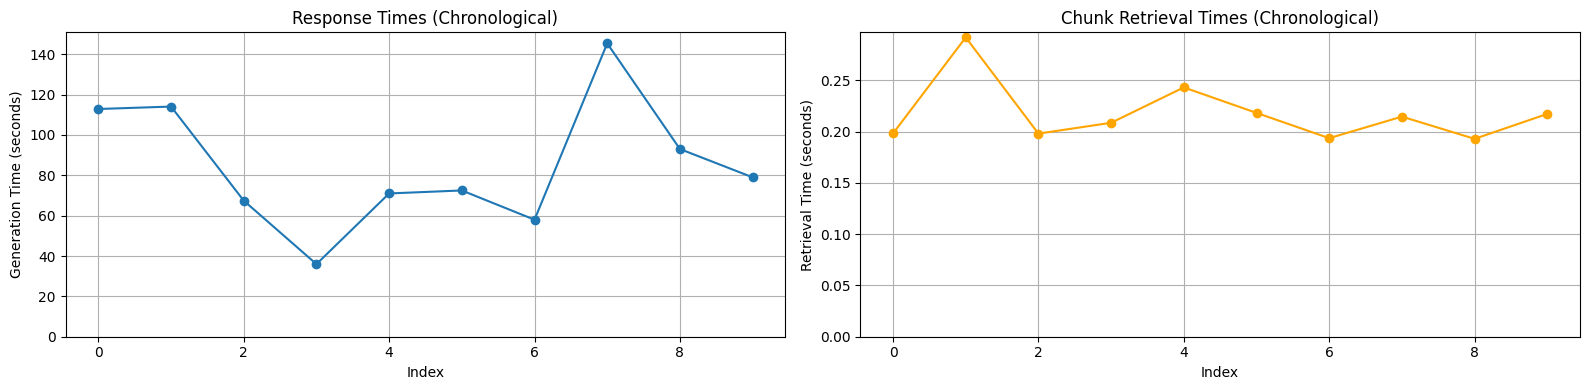

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)

axes[0].plot(results.index, results['generation_time'], marker='o', label='Generation Time')
axes[0].set_title('Response Times (Chronological)')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Generation Time (seconds)')
axes[0].set_ylim(0)
axes[0].grid(True)

axes[1].plot(results.index, results['chunk_retrieval_time'], marker='o', color='orange', label='Retrieval Time')
axes[1].set_title('Chunk Retrieval Times (Chronological)')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Retrieval Time (seconds)')
axes[1].set_ylim(0)
axes[1].grid(True)

plt.tight_layout()
plt.show()

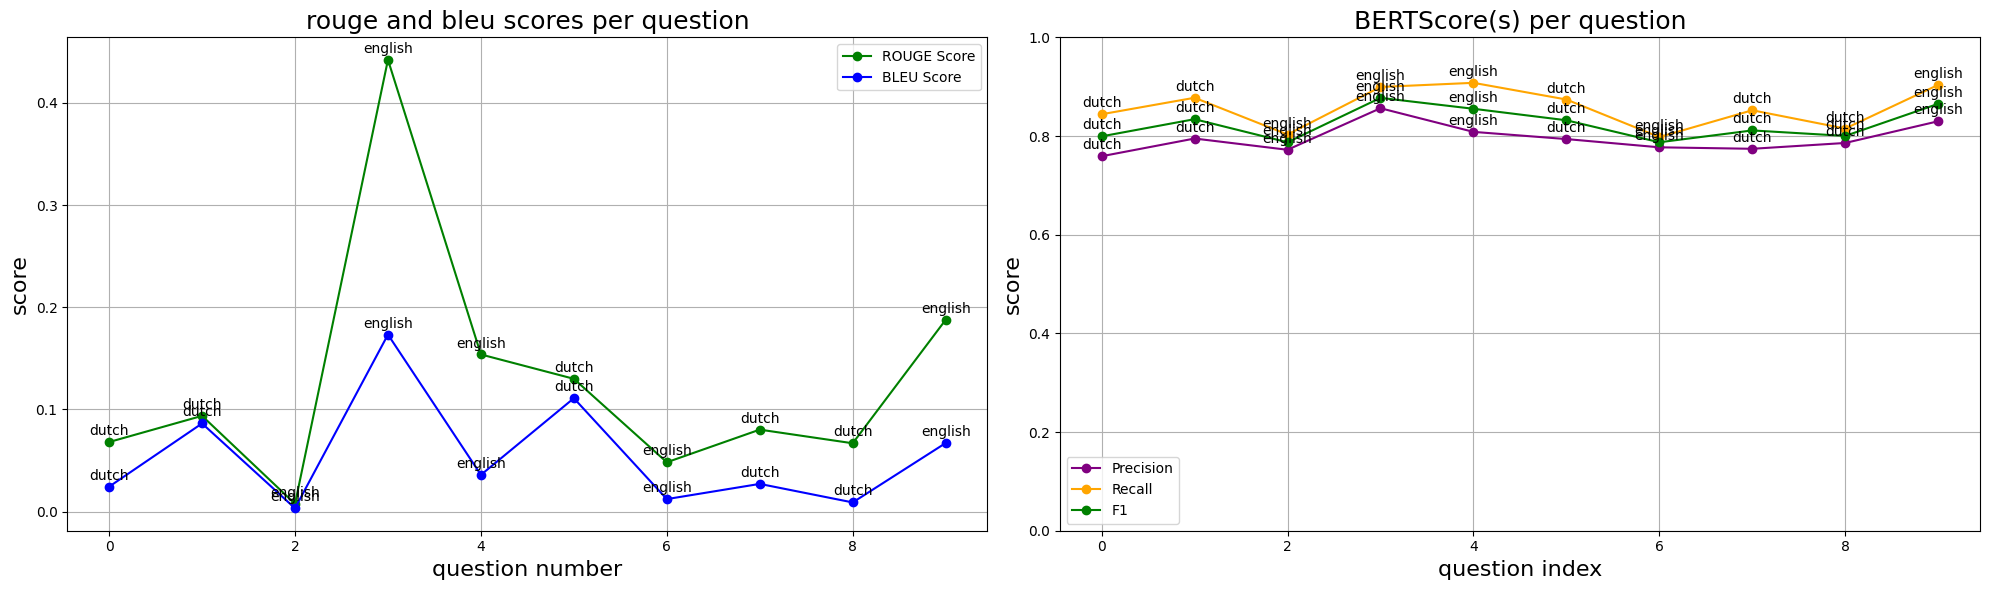

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].plot(results.index, results['rouge'], marker='o', label='ROUGE Score', color='green')
axes[0].plot(results.index, results['bleu'], marker='o', label='BLEU Score', color='blue')
axes[0].set_title('rouge and bleu scores per question', fontsize=18)
axes[0].set_xlabel('question number', fontsize=16)
axes[0].set_ylabel('score', fontsize=16)
axes[0].legend()
axes[0].grid(True)

# Add text above each point for the first plot
for i, txt in enumerate(results['original_language']):
  axes[0].annotate(txt, (results.index[i], results['rouge'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[0].annotate(txt, (results.index[i], results['bleu'][i]), textcoords="offset points", xytext=(0, 5), ha='center')

results['precision'] = results['precision'].apply(lambda x: float(str(x).strip("tensor([])")))
results['recall'] = results['recall'].apply(lambda x: float(str(x).strip("tensor([])")))
results['F1'] = results['F1'].apply(lambda x: float(str(x).strip("tensor([])")))
axes[1].plot(results.index, results['precision'], marker='o', label='Precision', color='purple')
axes[1].plot(results.index, results['recall'], marker='o', label='Recall', color='orange')
axes[1].plot(results.index, results['F1'], marker='o', label='F1', color='green')
axes[1].set_title('BERTScore(s) per question', fontsize=18)
axes[1].set_xlabel('question index', fontsize=16)
axes[1].set_ylabel('score', fontsize=16)
axes[1].legend()
axes[1].grid(True)
axes[1].set_ylim(0, 1)

# Add text above each point for the second plot
for i, txt in enumerate(results['original_language']):
  axes[1].annotate(txt, (results.index[i], results['precision'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[1].annotate(txt, (results.index[i], results['recall'][i]), textcoords="offset points", xytext=(0, 5), ha='center')
  axes[1].annotate(txt, (results.index[i], results['F1'][i]), textcoords="offset points", xytext=(0, 5), ha='center')

plt.tight_layout()
plt.show()

In [88]:
averages = results.mean(numeric_only=True)
print(averages)

chunk_retrieval_time     0.217700
generation_time         84.934068
bleu                     0.054987
rouge                    0.127890
precision                0.795150
recall                   0.857460
F1                       0.824910
recall@k                 0.800000
precision@k              0.400000
dtype: float64


first prompt:

chunk_retrieval_time     0.020129 -> 0.023403

generation_time         60.685850 -> 76.223767

bleu                     0.033003 -> 0.128261

rouge                    0.125113 -> 0.222738

precision                0.812940 -> 0.833550

recall                   0.859570 -> 0.862730

recall@k                 0.900000 -> 0.80000

precision@k              0.640000 -> 0.46000

dtype: float64

5 chunks retrieved using english query

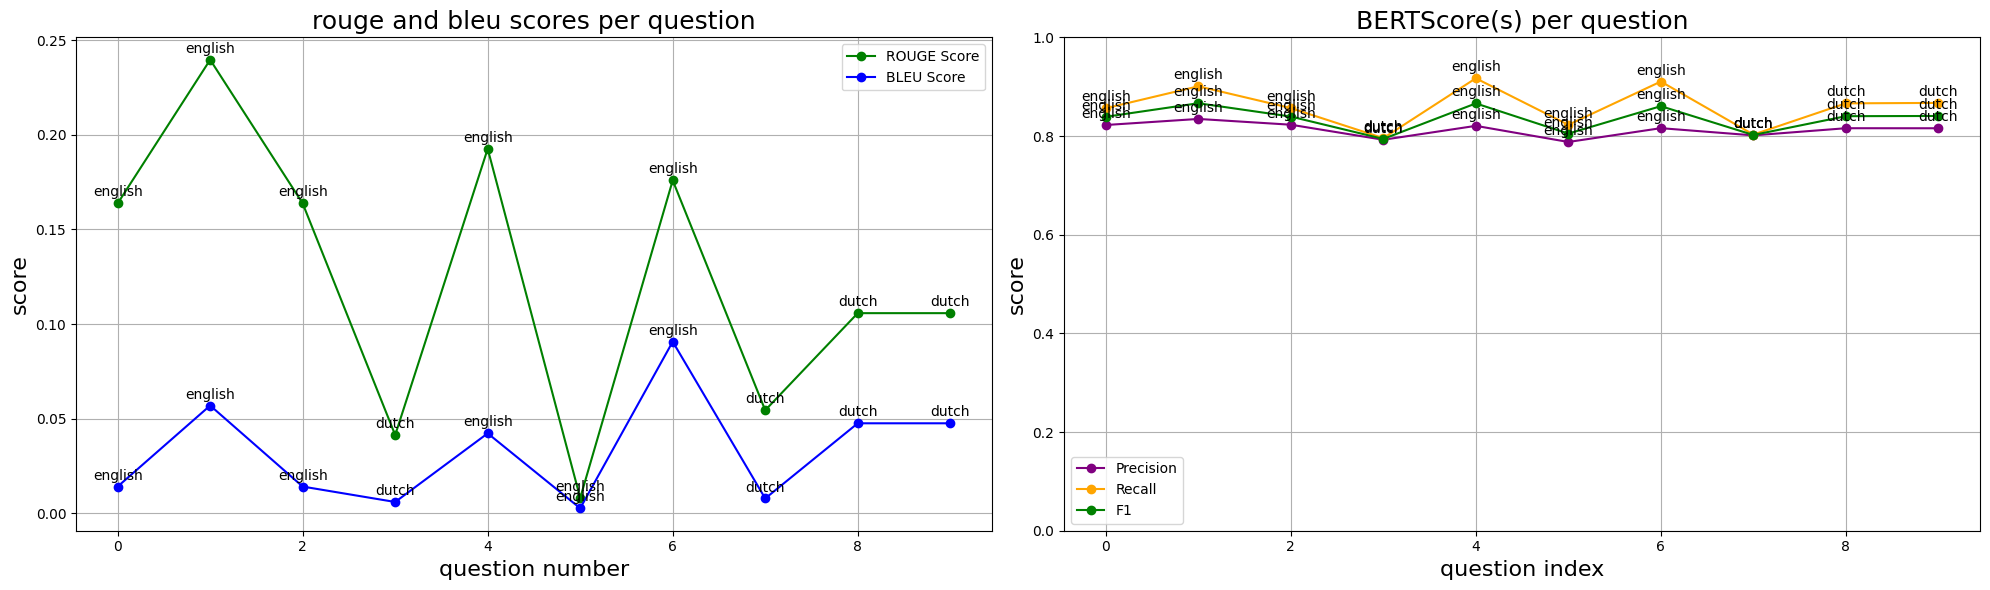


3 chunks retrieved using english query, and 3 chunks retrieved using translated dutch alternative

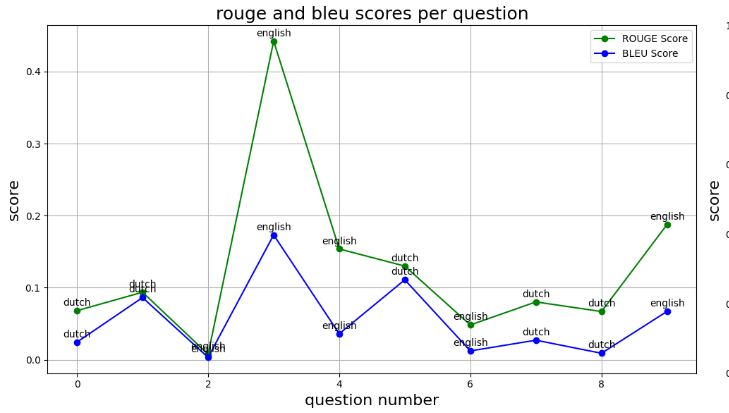


top 5 chunks combined for both english and dutch query